In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import joblib


In [3]:
from google.colab import files
uploaded=files.upload()

Saving IRIS.csv to IRIS.csv


In [5]:
df = pd.read_csv("IRIS.csv")

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
df.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,species
28,5.2,3.4,1.4,0.2,Iris-setosa
63,6.1,2.9,4.7,1.4,Iris-versicolor
33,5.5,4.2,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
48,5.3,3.7,1.5,0.2,Iris-setosa


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [8]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [9]:
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [10]:
df['species'] = df['species'].str.replace('Iris-', '')

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


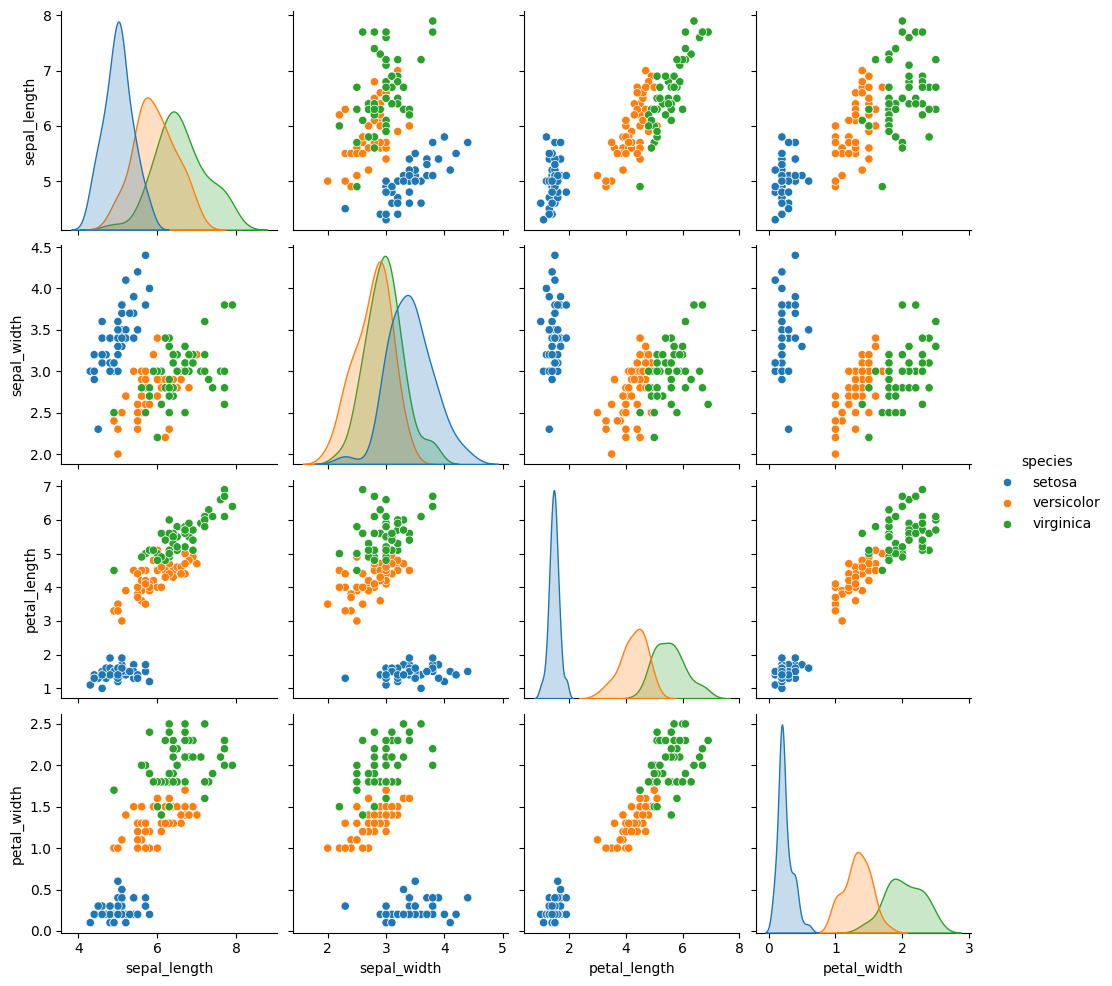

In [11]:
sns.pairplot(df, hue='species')

plt.show()

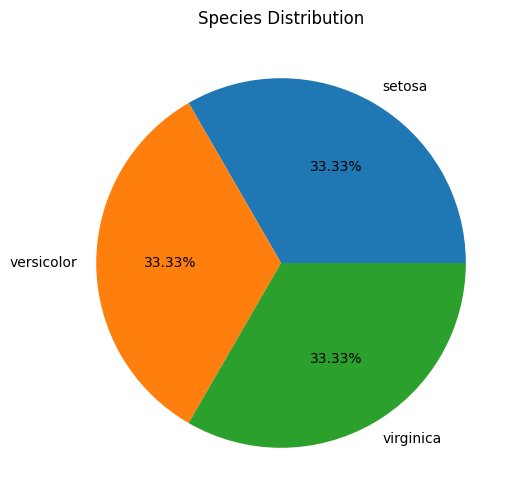

In [12]:
df['species'].value_counts().plot(
    kind='pie',
    autopct='%0.2f%%',
    figsize=(6,6)
)

plt.title("Species Distribution")

plt.ylabel("")

plt.show()

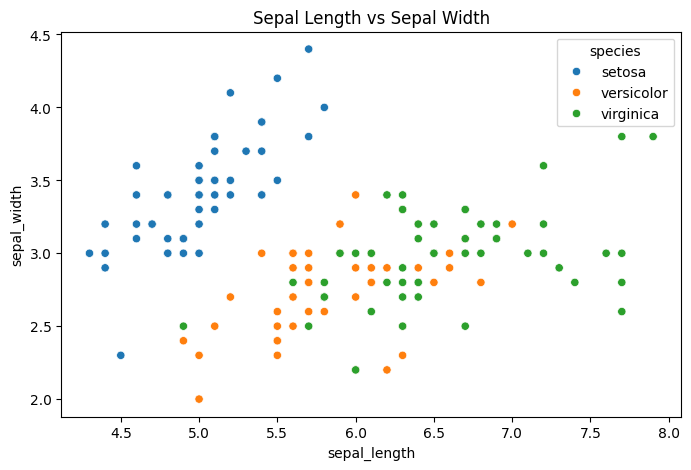

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='sepal_length',
    y='sepal_width',
    hue='species'
)

plt.title("Sepal Length vs Sepal Width")

plt.show()

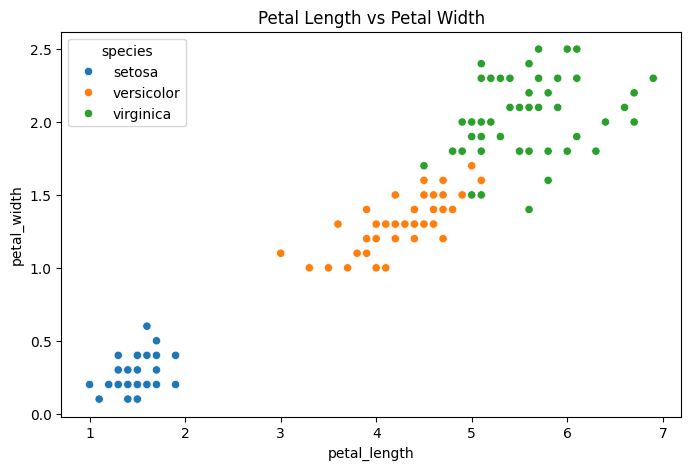

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='petal_length',
    y='petal_width',
    hue='species'
)

plt.title("Petal Length vs Petal Width")

plt.show()

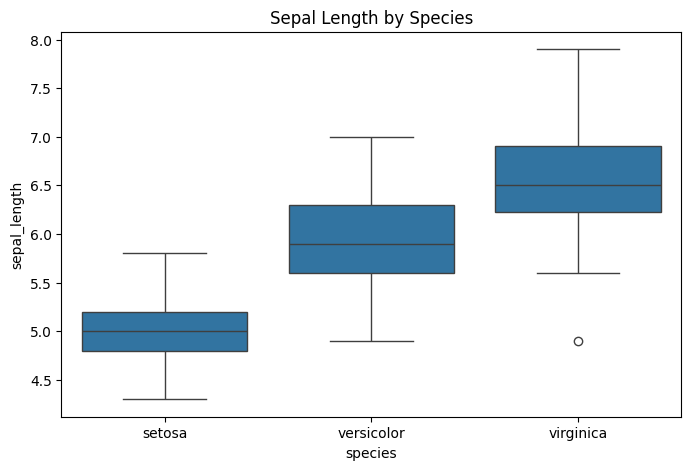

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='species',
    y='sepal_length'
)

plt.title("Sepal Length by Species")

plt.show()

In [16]:
le = LabelEncoder()

df['species'] = le.fit_transform(df['species'])

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [19]:
X = df.iloc[:, :-1]

y = df['species']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

log_acc = accuracy_score(y_test, log_pred)

print("Logistic Regression Accuracy:", log_acc)

Logistic Regression Accuracy: 1.0


In [22]:
knn_model = KNeighborsClassifier(n_neighbors=3)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_acc)

KNN Accuracy: 1.0


In [23]:
dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 1.0


In [24]:
print("Model Accuracy Comparison")

print("--------------------------")

print("Logistic Regression:", log_acc)

print("KNN:", knn_acc)

print("Decision Tree:", dt_acc)

Model Accuracy Comparison
--------------------------
Logistic Regression: 1.0
KNN: 1.0
Decision Tree: 1.0


In [25]:
cm = confusion_matrix(y_test, log_pred)

print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [26]:
print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [27]:
joblib.dump(log_model, "best_iris_model.pkl")

print("Best Model Saved Successfully")

Best Model Saved Successfully


In [29]:
sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = log_model.predict(sample)

print("Predicted Class:", prediction)

Predicted Class: [0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [32]:
files.download("best_iris_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>